# Phase 3 — Notebook 13: Interpretability & Report

This notebook consolidates interpretability artifacts from the hybrid stack:
- BN posterior distributions under evidence scenarios
- Interface Layer outputs (hard evidence and virtual evidence)
- Phase 1 → 2 → 3 progression summary table
- CPT comparison: seed values vs EM-trained values

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

# Ensure project root is importable when notebook runs from notebooks/Phase_3.
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "Phase_3":
    PROJECT_ROOT = PROJECT_ROOT.parent.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.phase3.bayesian.bootstrap import ensure_seed_model
from src.phase3.bayesian.em_trainer import load_model
from src.phase3.bayesian.inference import run_inference

print(f"Project root: {PROJECT_ROOT}")

/Users/subhammahapatra/Downloads/agastya/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: /Users/subhammahapatra/Downloads/agastya


## Section 1 — BN Posterior Distributions Under Evidence Scenarios

In [2]:
model_path = ensure_seed_model(str(PROJECT_ROOT / "results" / "phase3" / "bayesian_network.pkl"))
model = load_model(model_path)

scenarios = {
    "No Evidence": {},
    "Payment+Termination Present": {
        "Has_Payment_Clause": "Present",
        "Has_Termination_Clause": "Present",
    },
    "All Core Clauses Present": {
        "Has_Payment_Clause": "Present",
        "Has_Termination_Clause": "Present",
        "Has_Liability_Clause": "Present",
        "Has_Confidentiality_Clause": "Present",
        "Has_Dispute_Resolution_Clause": "Present",
    },
    "Risky + No Dispute Clause": {
        "Has_Payment_Clause": "Present",
        "Has_Termination_Clause": "Present",
        "Has_Liability_Clause": "Present",
        "Has_Confidentiality_Clause": "Present",
        "Has_Dispute_Resolution_Clause": "Absent",
    },
}

rows = []
for name, ev in scenarios.items():
    out = run_inference(model, evidence=ev)
    rows.append(
        {
            "scenario": name,
            **out["probabilities"],
            "predicted_risk": out["risk_level"],
        }
    )

posterior_df = pd.DataFrame(rows)
posterior_df

,scenario,High,Low,Medium,predicted_risk
0,No Evidence,0.587797,0.194437,0.217766,High
1,Payment+Termination Present,0.682867,0.104889,0.212244,High
2,All Core Clauses Present,0.794224,0.000000,0.205776,High
3,Risky + No Dispute Clause,0.794224,0.000000,0.205776,High


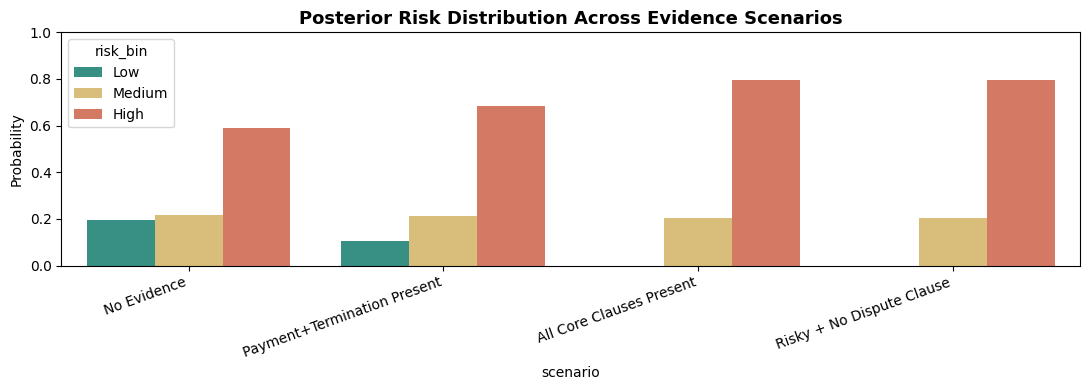

In [3]:
viz_df = posterior_df.melt(
    id_vars=["scenario", "predicted_risk"],
    value_vars=["Low", "Medium", "High"],
    var_name="risk_bin",
    value_name="probability",
)

palette = {"Low": "#2A9D8F", "Medium": "#E9C46A", "High": "#E76F51"}
plt.figure(figsize=(11, 4))
sns.barplot(data=viz_df, x="scenario", y="probability", hue="risk_bin", palette=palette)
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.title("Posterior Risk Distribution Across Evidence Scenarios", fontsize=13, fontweight="bold")
plt.ylabel("Probability")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "phase3" / "figures" / "posterior_scenarios.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 2 — Phase Progression Summary

In [4]:
# Load real metric values from artifact files
def _load_metric(path: Path, key: str, fallback=float("nan")):
    if path.exists():
        data = json.loads(path.read_text(encoding="utf-8"))
        val = data.get(key)
        return float(val) if val is not None else fallback
    return fallback

p1_f1 = _load_metric(PROJECT_ROOT / "results" / "phase1" / "results.json", "macro_f1")
p2_f1 = _load_metric(PROJECT_ROOT / "results" / "phase2" / "results.json", "macro_f1")
p3_f1 = _load_metric(PROJECT_ROOT / "reports" / "phase3" / "hybrid_eval.json", "macro_f1")
p3_n  = _load_metric(PROJECT_ROOT / "reports" / "phase3" / "hybrid_eval.json", "n_contracts", fallback=0)

phase_progression = pd.DataFrame(
    [
        {
            "Phase": "Phase 1",
            "Core Model": "LinearSVC + TF-IDF",
            "Task": "Per-clause type (41 CUAD categories)",
            "Macro-F1": p1_f1,
            "Strength": "Transparent, interpretable baseline",
            "MetricStatus": "reported",
        },
        {
            "Phase": "Phase 2",
            "Core Model": "Legal-BERT (nlpaueb/legal-bert-base-uncased)",
            "Task": "Per-clause type (41 CUAD categories)",
            "Macro-F1": p2_f1,
            "Strength": "Context-aware clause encoding (+0.027 vs Phase 1)",
            "MetricStatus": "reported",
        },
        {
            "Phase": "Phase 3",
            "Core Model": "Legal-BERT + Bayesian Network (pgmpy)",
            "Task": f"Contract-level risk (Low/Med/High, n={int(p3_n)} contracts)",
            "Macro-F1": p3_f1,
            "Strength": "Neuro-symbolic reasoning + probabilistic risk traceability",
            "MetricStatus": "from_hybrid_eval_artifact",
        },
    ]
)

print(f"Phase 1 Macro-F1: {p1_f1:.4f}")
print(f"Phase 2 Macro-F1: {p2_f1:.4f}  (Δ = +{p2_f1 - p1_f1:+.4f} vs Phase 1)")
print(f"Phase 3 Macro-F1: {p3_f1:.4f}  (contract-level 3-class risk task)")
phase_progression

Phase 1 Macro-F1: 0.7187
Phase 2 Macro-F1: 0.7463  (Δ = ++0.0276 vs Phase 1)
Phase 3 Macro-F1: 0.5793  (contract-level 3-class risk task)


,Phase,Core Model,Task,Macro-F1,Strength,MetricStatus
0,Phase 1,LinearSVC + TF-IDF,Per-clause type (41 CUAD categories),0.718700,"Transparent, interpretable baseline",reported
1,Phase 2,Legal-BERT (nlpaueb/legal-bert-base-uncased),Per-clause type (41 CUAD categories),0.746321,Context-aware clause encoding (+0.027 vs Phase 1),reported
2,Phase 3,Legal-BERT + Bayesian Network (pgmpy),"Contract-level risk (Low/Med/High, n=51 contra...",0.579266,Neuro-symbolic reasoning + probabilistic risk ...,from_hybrid_eval_artifact


In [5]:
reports_dir = PROJECT_ROOT / "reports" / "phase3"
reports_dir.mkdir(parents=True, exist_ok=True)
posterior_path = reports_dir / "posterior_scenarios.csv"
progression_path = reports_dir / "phase_progression_summary.csv"
posterior_df.to_csv(posterior_path, index=False)
phase_progression.to_csv(progression_path, index=False)
print("Saved:")
print(f"- {posterior_path}")
print(f"- {progression_path}")

Saved:
- /Users/subhammahapatra/Downloads/agastya/reports/phase3/posterior_scenarios.csv
- /Users/subhammahapatra/Downloads/agastya/reports/phase3/phase_progression_summary.csv
